In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from scipy import stats

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Changement de répertoire vers la racine du projet
os.chdir("../")

In [2]:
# Import des fonctions personnalisées
from src.feature_engineering import apply_robust_scaler, apply_target_encoding, apply_catboost_encoding
from src.evaluation import evaluate_model, time_series_expanding_window

train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")
print(f"Période train: {train['date'].min()} à {train['date'].max()}")
print(f"Période test: {test['date'].min()} à {test['date'].max()}")


Train: (2901096, 47)
Test: (99792, 47)
Période train: 2013-01-01 00:00:00 à 2017-06-20 00:00:00
Période test: 2017-06-21 00:00:00 à 2017-08-15 00:00:00


## Un seul Magasin

In [3]:
# ============================================================================
# SÉLECTION DU SOUS-ENSEMBLE
# ============================================================================
selected_store = 1
selected_family = 'GROCERY I'

print(f"\n=== Sélection: Magasin {selected_store}, Famille {selected_family} ===")

train_subset = train[
    (train['store_nbr'] == selected_store) & 
    (train['family'] == selected_family)
].copy().sort_values('date').reset_index(drop=True)

test_subset = test[
    (test['store_nbr'] == selected_store) & 
    (test['family'] == selected_family)
].copy().sort_values('date').reset_index(drop=True)

print(f"Train subset: {train_subset.shape}")
print(f"Test subset: {test_subset.shape}")
print(f"\nStatistiques des ventes:")
print(train_subset['sales'].describe())
print(f"Jours avec ventes = 0: {(train_subset['sales'] == 0).sum()} ({(train_subset['sales'] == 0).mean()*100:.1f}%)")


=== Sélection: Magasin 1, Famille GROCERY I ===
Train subset: (1628, 47)
Test subset: (56, 47)

Statistiques des ventes:
count    1628.000000
mean     2214.934814
std       782.164185
min         0.000000
25%      1868.000000
50%      2265.500000
75%      2633.500000
max      9065.000000
Name: sales, dtype: float64
Jours avec ventes = 0: 6 (0.4%)


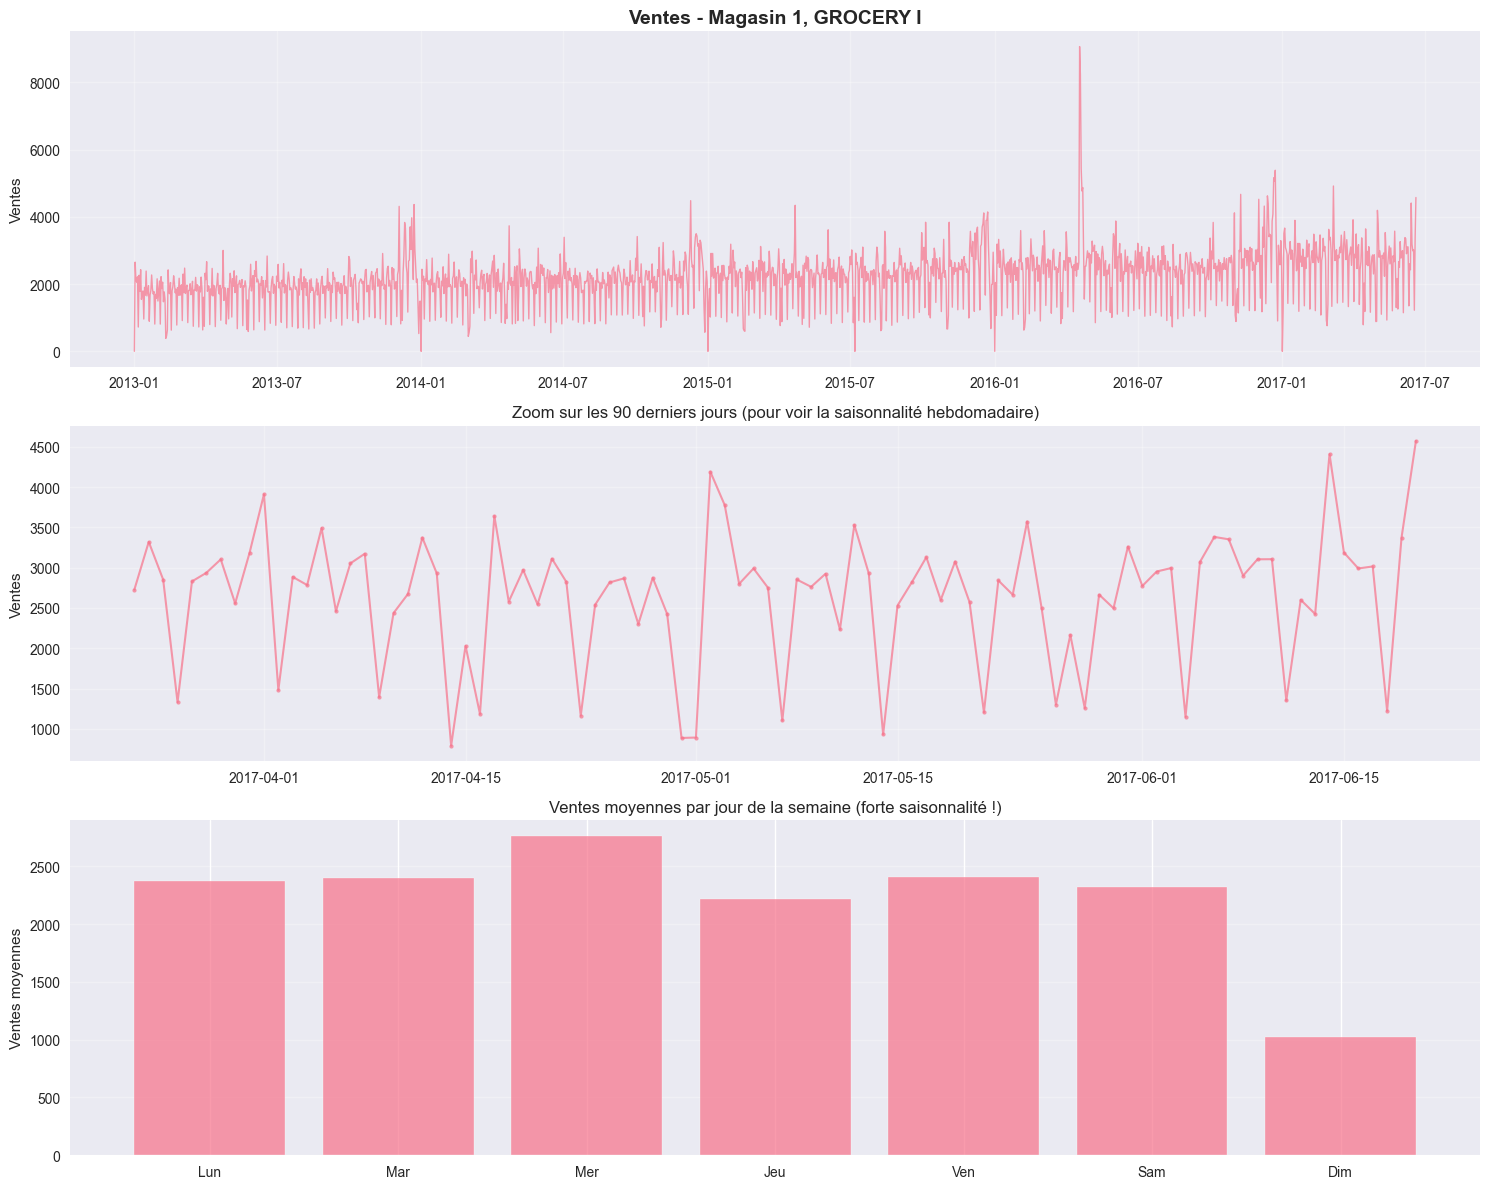

✓ Saisonnalité hebdomadaire clairement visible !


In [5]:
# ============================================================================
# VISUALISATION INITIALE
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Série complète
axes[0].plot(train_subset['date'], train_subset['sales'], alpha=0.7, linewidth=1)
axes[0].set_title(f'Ventes - Magasin {selected_store}, {selected_family}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ventes')
axes[0].grid(True, alpha=0.3)

# Derniers 90 jours pour voir la saisonnalité
last_90 = train_subset.tail(90)
axes[1].plot(last_90['date'], last_90['sales'], alpha=0.7, linewidth=1.5, marker='o', markersize=3)
axes[1].set_title('Zoom sur les 90 derniers jours (pour voir la saisonnalité hebdomadaire)', fontsize=12)
axes[1].set_ylabel('Ventes')
axes[1].grid(True, alpha=0.3)

# Décomposition par jour de la semaine
train_subset['day_of_week'] = pd.to_datetime(train_subset['date']).dt.dayofweek
daily_avg = train_subset.groupby('day_of_week')['sales'].mean()
axes[2].bar(range(7), daily_avg, alpha=0.7)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])
axes[2].set_title('Ventes moyennes par jour de la semaine (forte saisonnalité !)', fontsize=12)
axes[2].set_ylabel('Ventes moyennes')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Saisonnalité hebdomadaire clairement visible !")


In [6]:
# ============================================================================
# PRÉPARATION DES DONNÉES POUR SARIMA
# ============================================================================

# On travaille avec la série brute (pas de log pour commencer)
# Si on fait un log, il faut gérer les 0
y_train = train_subset['sales'].values

# Alternative avec log si besoin (pour stabiliser la variance)
# Mais attention à bien gérer les 0 !
use_log_transform = True

if use_log_transform:
    print("Utilisation de la transformation log(1+x)...")
    y_train_transformed = np.log1p(y_train)  # log(1+x) pour gérer les 0
    transform_name = "log(1+x)"
else:
    print("Utilisation des valeurs brutes...")
    y_train_transformed = y_train
    transform_name = "valeurs brutes"

print(f"Série pour l'entraînement : {len(y_train_transformed)} observations")
print(f"Min: {y_train_transformed.min():.2f}, Max: {y_train_transformed.max():.2f}")
print(f"Moyenne: {y_train_transformed.mean():.2f}, Std: {y_train_transformed.std():.2f}")


Utilisation de la transformation log(1+x)...
Série pour l'entraînement : 1628 observations
Min: 0.00, Max: 9.11
Moyenne: 7.61, Std: 0.61


In [7]:

# ============================================================================
# TEST DE STATIONNARITÉ
# ============================================================================
def check_stationarity(series, title="Série"):
    """Test ADF de stationnarité"""
    result = adfuller(pd.Series(series).dropna())
    print(f"\n{title}")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Valeurs critiques:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.3f}")
    
    is_stationary = result[1] <= 0.05
    if is_stationary:
        print(f"  ✓ Série STATIONNAIRE (p-value <= 0.05)")
    else:
        print(f"  ✗ Série NON-STATIONNAIRE (p-value > 0.05)")
    return is_stationary

# Test sur la série transformée
is_stationary = check_stationarity(y_train_transformed, f"Série originale ({transform_name})")

# Test après différenciation d=1
y_diff1 = pd.Series(y_train_transformed).diff().dropna()
is_stationary_diff1 = check_stationarity(y_diff1, "Après différenciation d=1")



Série originale (log(1+x))
  ADF Statistic: -6.236470
  p-value: 0.000000
  Valeurs critiques:
    1%: -3.434
    5%: -2.863
    10%: -2.568
  ✓ Série STATIONNAIRE (p-value <= 0.05)

Après différenciation d=1
  ADF Statistic: -16.754671
  p-value: 0.000000
  Valeurs critiques:
    1%: -3.434
    5%: -2.863
    10%: -2.568
  ✓ Série STATIONNAIRE (p-value <= 0.05)


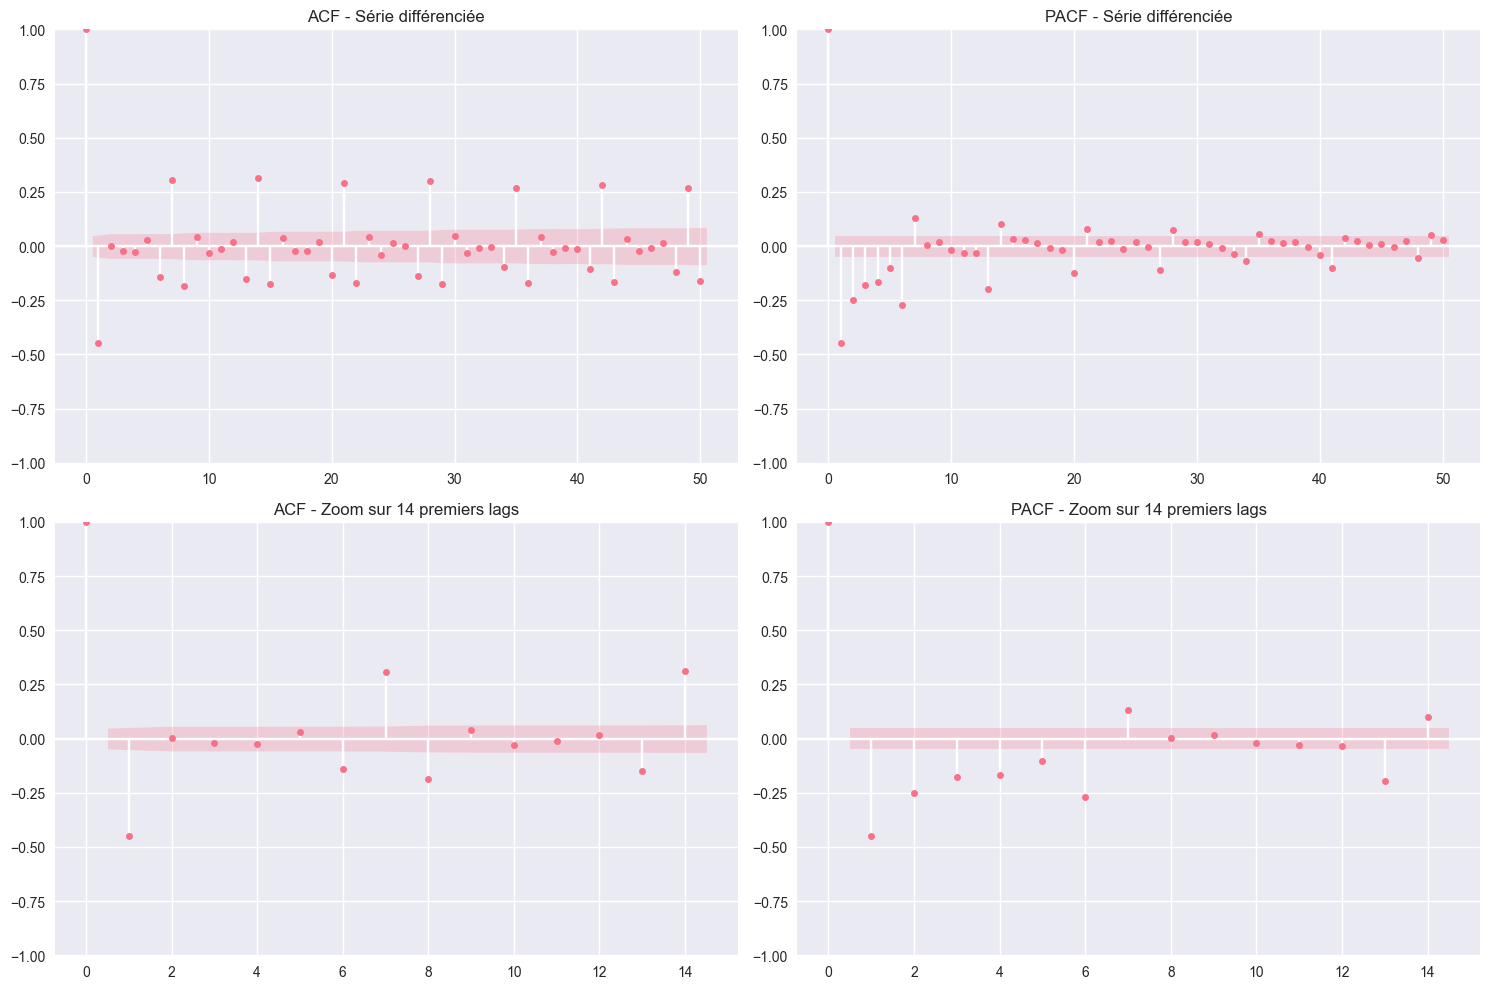

✓ Regardez les pics à lag=7, 14, 21... → saisonnalité hebdomadaire !


In [8]:
# ============================================================================
# ANALYSE ACF/PACF
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF/PACF sur série différenciée
series_for_acf = y_diff1

plot_acf(series_for_acf, ax=axes[0,0], lags=min(50, len(series_for_acf)//2), title='ACF - Série différenciée')
plot_pacf(series_for_acf, ax=axes[0,1], lags=min(50, len(series_for_acf)//2), title='PACF - Série différenciée')

# Zoom sur les premiers lags
plot_acf(series_for_acf, ax=axes[1,0], lags=14, title='ACF - Zoom sur 14 premiers lags')
plot_pacf(series_for_acf, ax=axes[1,1], lags=14, title='PACF - Zoom sur 14 premiers lags')

plt.tight_layout()
plt.show()

print("✓ Regardez les pics à lag=7, 14, 21... → saisonnalité hebdomadaire !")


In [9]:
# ============================================================================
# RECHERCHE DES MEILLEURS PARAMÈTRES SARIMA
# ============================================================================

# Paramètres à tester
# (p, d, q) x (P, D, Q, s)
# s=7 pour saisonnalité hebdomadaire

# On teste plusieurs combinaisons (version rapide)
param_combinations = [
    # (p,d,q), (P,D,Q,s)
    ((1, 1, 1), (1, 1, 1, 7)),  # SARIMA classique
    ((2, 1, 2), (1, 1, 1, 7)),  # Un peu plus complexe
    ((1, 1, 2), (1, 1, 1, 7)),
    ((2, 1, 1), (1, 1, 1, 7)),
    ((1, 1, 1), (2, 1, 1, 7)),
    ((0, 1, 1), (1, 1, 1, 7)),
    ((1, 1, 0), (1, 1, 1, 7)),
]


results = []

Test de 7 combinaisons de paramètres...
(Cela peut prendre quelques minutes)


In [10]:
for order, seasonal_order in param_combinations:
    try:
        # Entraînement du modèle
        model = SARIMAX(
            y_train_transformed,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted_model = model.fit(disp=False, maxiter=100)

        # Métriques
        aic = fitted_model.aic
        bic = fitted_model.bic

        results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': aic,
            'bic': bic,
            'model': fitted_model
        })

        print(f"  SARIMA{order}x{seasonal_order}: AIC={aic:.2f}, BIC={bic:.2f}")

    except Exception as e:
        print(f"  SARIMA{order}x{seasonal_order}: ERREUR - {str(e)[:80]}")

  SARIMA(1, 1, 1)x(1, 1, 1, 7): AIC=2448.06, BIC=2474.99
  SARIMA(2, 1, 2)x(1, 1, 1, 7): AIC=2445.36, BIC=2483.04
  SARIMA(1, 1, 2)x(1, 1, 1, 7): AIC=2443.36, BIC=2475.66
  SARIMA(2, 1, 1)x(1, 1, 1, 7): AIC=2447.73, BIC=2480.04
  SARIMA(1, 1, 1)x(2, 1, 1, 7): AIC=2443.14, BIC=2475.43
  SARIMA(0, 1, 1)x(1, 1, 1, 7): AIC=2462.37, BIC=2483.91
  SARIMA(1, 1, 0)x(1, 1, 1, 7): AIC=2994.66, BIC=3016.20


In [11]:
# Tri par AIC
results_df = pd.DataFrame([
    {
        'order': r['order'],
        'seasonal_order': r['seasonal_order'],
        'aic': r['aic'],
        'bic': r['bic']
    }
    for r in results
])

In [12]:

if len(results_df) > 0:
    results_df = results_df.sort_values('aic')
    print("\n=== Top 5 des meilleurs modèles (par AIC) ===")
    print(results_df.head())

    # Meilleur modèle
    best_result = results[results_df.index[0]]
    best_model = best_result['model']
    best_order = best_result['order']
    best_seasonal_order = best_result['seasonal_order']

    print(f"\n✓ MEILLEUR MODÈLE: SARIMA{best_order}x{best_seasonal_order}")
    print(f"  AIC: {best_result['aic']:.2f}")
    print(f"  BIC: {best_result['bic']:.2f}")
else:
    print("ERREUR: Aucun modèle n'a convergé !")
    best_model = None


=== Top 5 des meilleurs modèles (par AIC) ===
       order seasonal_order          aic          bic
4  (1, 1, 1)   (2, 1, 1, 7)  2443.140644  2475.425918
2  (1, 1, 2)   (1, 1, 1, 7)  2443.356176  2475.660113
1  (2, 1, 2)   (1, 1, 1, 7)  2445.356039  2483.043965
3  (2, 1, 1)   (1, 1, 1, 7)  2447.733449  2480.041111
0  (1, 1, 1)   (1, 1, 1, 7)  2448.064214  2474.987266

✓ MEILLEUR MODÈLE: SARIMA(1, 1, 1)x(2, 1, 1, 7)
  AIC: 2443.14
  BIC: 2475.43



DIAGNOSTIC DU MODÈLE
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1628
Model:             SARIMAX(1, 1, 1)x(2, 1, 1, 7)   Log Likelihood               -1215.570
Date:                           Sat, 31 Jan 2026   AIC                           2443.141
Time:                                   15:24:46   BIC                           2475.426
Sample:                                        0   HQIC                          2455.127
                                          - 1628                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1008      0.022      4.564      0.000       0.058       0.144
ma.L1         -1.0000

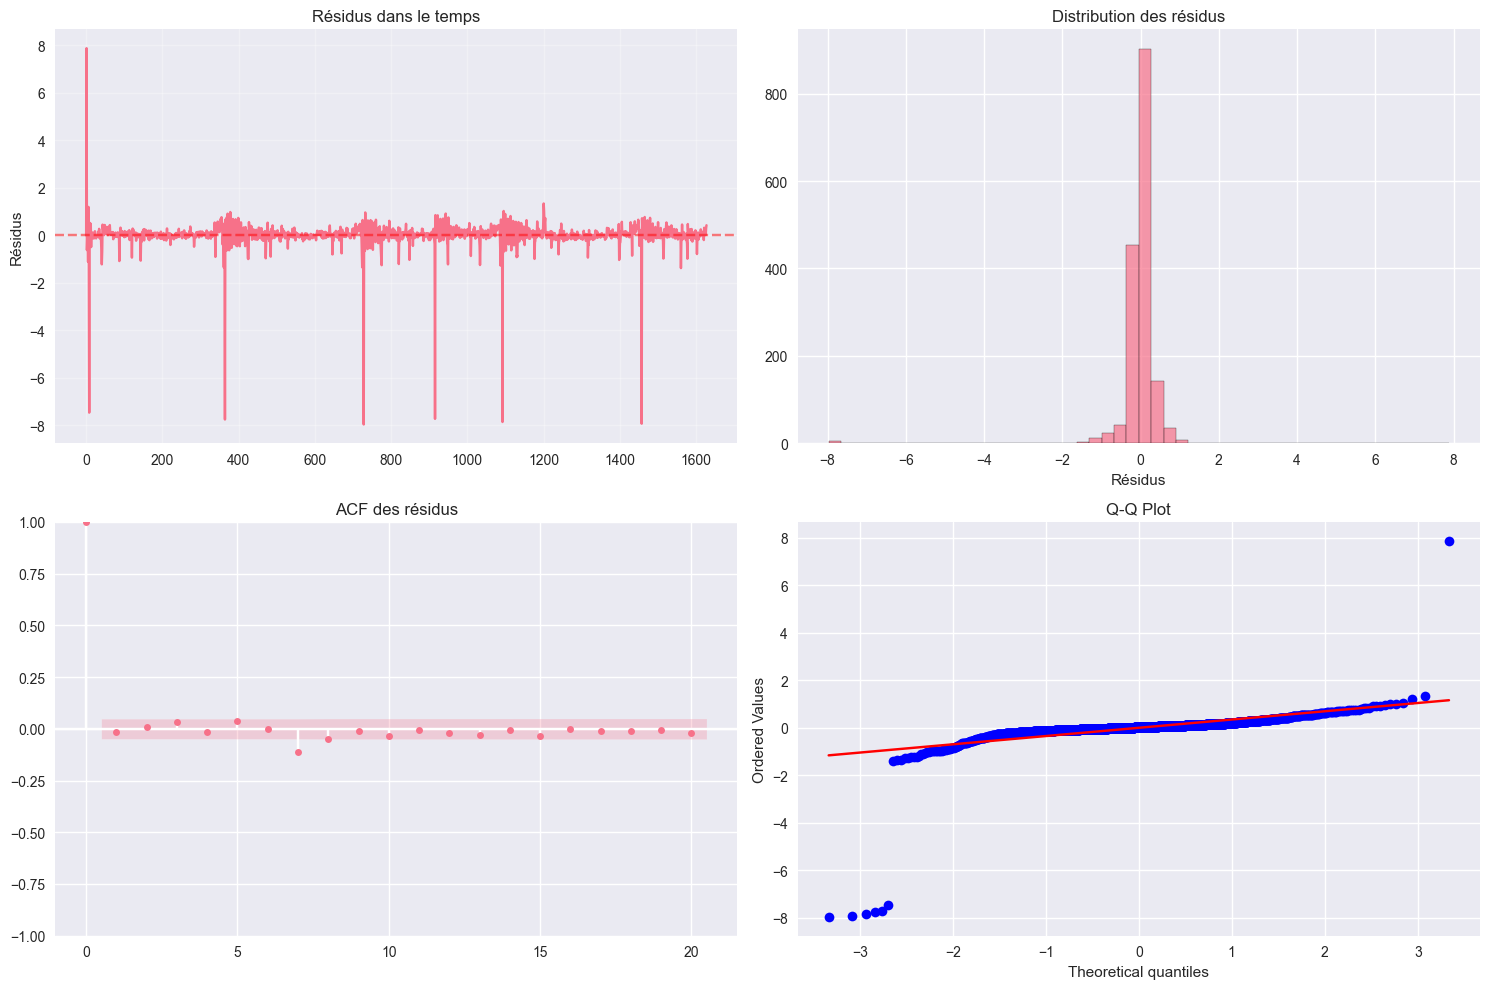


Statistiques des résidus:
  Moyenne: -0.001008 (devrait être proche de 0)
  Écart-type: 0.579609
  Skewness: -7.465634 (devrait être proche de 0)
  Kurtosis: 139.010465 (devrait être proche de 0)


In [13]:

# ============================================================================
# DIAGNOSTIC DU MODÈLE
# ============================================================================
if best_model is not None:
    print("\n" + "="*80)
    print("DIAGNOSTIC DU MODÈLE")
    print("="*80)

    print(best_model.summary())

    # Résidus
    residuals = best_model.resid

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Résidus dans le temps
    axes[0,0].plot(residuals)
    axes[0,0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0,0].set_title('Résidus dans le temps')
    axes[0,0].set_ylabel('Résidus')
    axes[0,0].grid(True, alpha=0.3)

    # Histogramme
    axes[0,1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[0,1].set_title('Distribution des résidus')
    axes[0,1].set_xlabel('Résidus')

    # ACF des résidus
    plot_acf(residuals, ax=axes[1,0], lags=20, title='ACF des résidus')

    # Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[1,1])
    axes[1,1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

    print(f"\nStatistiques des résidus:")
    print(f"  Moyenne: {residuals.mean():.6f} (devrait être proche de 0)")
    print(f"  Écart-type: {residuals.std():.6f}")
    print(f"  Skewness: {stats.skew(residuals):.6f} (devrait être proche de 0)")
    print(f"  Kurtosis: {stats.kurtosis(residuals):.6f} (devrait être proche de 0)")

In [14]:
# ============================================================================
# PRÉDICTIONS SUR LE TEST
# ============================================================================
if best_model is not None:

    n_forecast = len(test_subset)
    print(f"Nombre de prédictions à faire: {n_forecast}")

    # Prédictions (dans l'espace transformé)
    forecast_result = best_model.forecast(steps=n_forecast)
    forecast_transformed = forecast_result

    # Retransformation dans l'espace original
    if use_log_transform:
        # Inverse de log(1+x) est exp(x)-1
        forecast_sales = np.expm1(forecast_transformed)
    else:
        forecast_sales = forecast_transformed

    # Pas de ventes négatives
    forecast_sales = np.maximum(forecast_sales, 0)

    # Ajout au dataframe
    test_subset['predicted_sales'] = forecast_sales

    print(f"\nStatistiques des prédictions:")
    print(f"  Min: {forecast_sales.min():.2f}")
    print(f"  Max: {forecast_sales.max():.2f}")
    print(f"  Moyenne: {forecast_sales.mean():.2f}")
    print(f"  Std: {forecast_sales.std():.2f}")

    print(f"\nStatistiques des vraies valeurs:")
    print(f"  Min: {test_subset['sales'].min():.2f}")
    print(f"  Max: {test_subset['sales'].max():.2f}")
    print(f"  Moyenne: {test_subset['sales'].mean():.2f}")
    print(f"  Std: {test_subset['sales'].std():.2f}")

    # Vérification : les prédictions varient-elles ?
    if forecast_sales.std() < 1e-6:
        print("\n⚠️  ATTENTION: Les prédictions sont constantes !")
    else:
        print(f"\n✓ Les prédictions varient (std={forecast_sales.std():.2f})")

Nombre de prédictions à faire: 56

Statistiques des prédictions:
  Min: 1214.20
  Max: 3538.39
  Moyenne: 2696.19
  Std: 651.19

Statistiques des vraies valeurs:
  Min: 952.00
  Max: 3370.00
  Moyenne: 2462.66
  Std: 651.88

✓ Les prédictions varient (std=651.19)


In [15]:
# ============================================================================
# ÉVALUATION
# ============================================================================
if best_model is not None and 'predicted_sales' in test_subset.columns:


    # Utilisation de la fonction d'évaluation personnalisée
    metrics = evaluate_model(
        y_true=test_subset['sales'].values,
        y_pred=test_subset['predicted_sales'].values,
        is_store_closed=test_subset['is_store_closed'].values,
        is_family_unactive=test_subset['is_family_unactive'].values
    )

    # Métriques supplémentaires
    mask_active = (test_subset['is_store_closed'] == 0) & (test_subset['is_family_unactive'] == 0)
    mask_nonzero = (test_subset['sales'] > 0) & mask_active

    if mask_nonzero.sum() > 0:
        mape = np.mean(np.abs((test_subset.loc[mask_nonzero, 'sales'] -
                              test_subset.loc[mask_nonzero, 'predicted_sales']) /
                              test_subset.loc[mask_nonzero, 'sales'])) * 100
        print(f"\nMAPE (sur ventes > 0): {mape:.2f}%")

    if mask_active.sum() > 1:
        correlation = np.corrcoef(
            test_subset.loc[mask_active, 'sales'],
            test_subset.loc[mask_active, 'predicted_sales']
        )[0, 1]
        print(f"Corrélation: {correlation:.4f}")

--- Evaluation (sur 56 points actifs) ---
Weighted MAE   : 322.0419
Weighted RMSE  : 433.3358
Weighted RMSLE : 0.1862

MAPE (sur ventes > 0): 15.00%
Corrélation: 0.8417


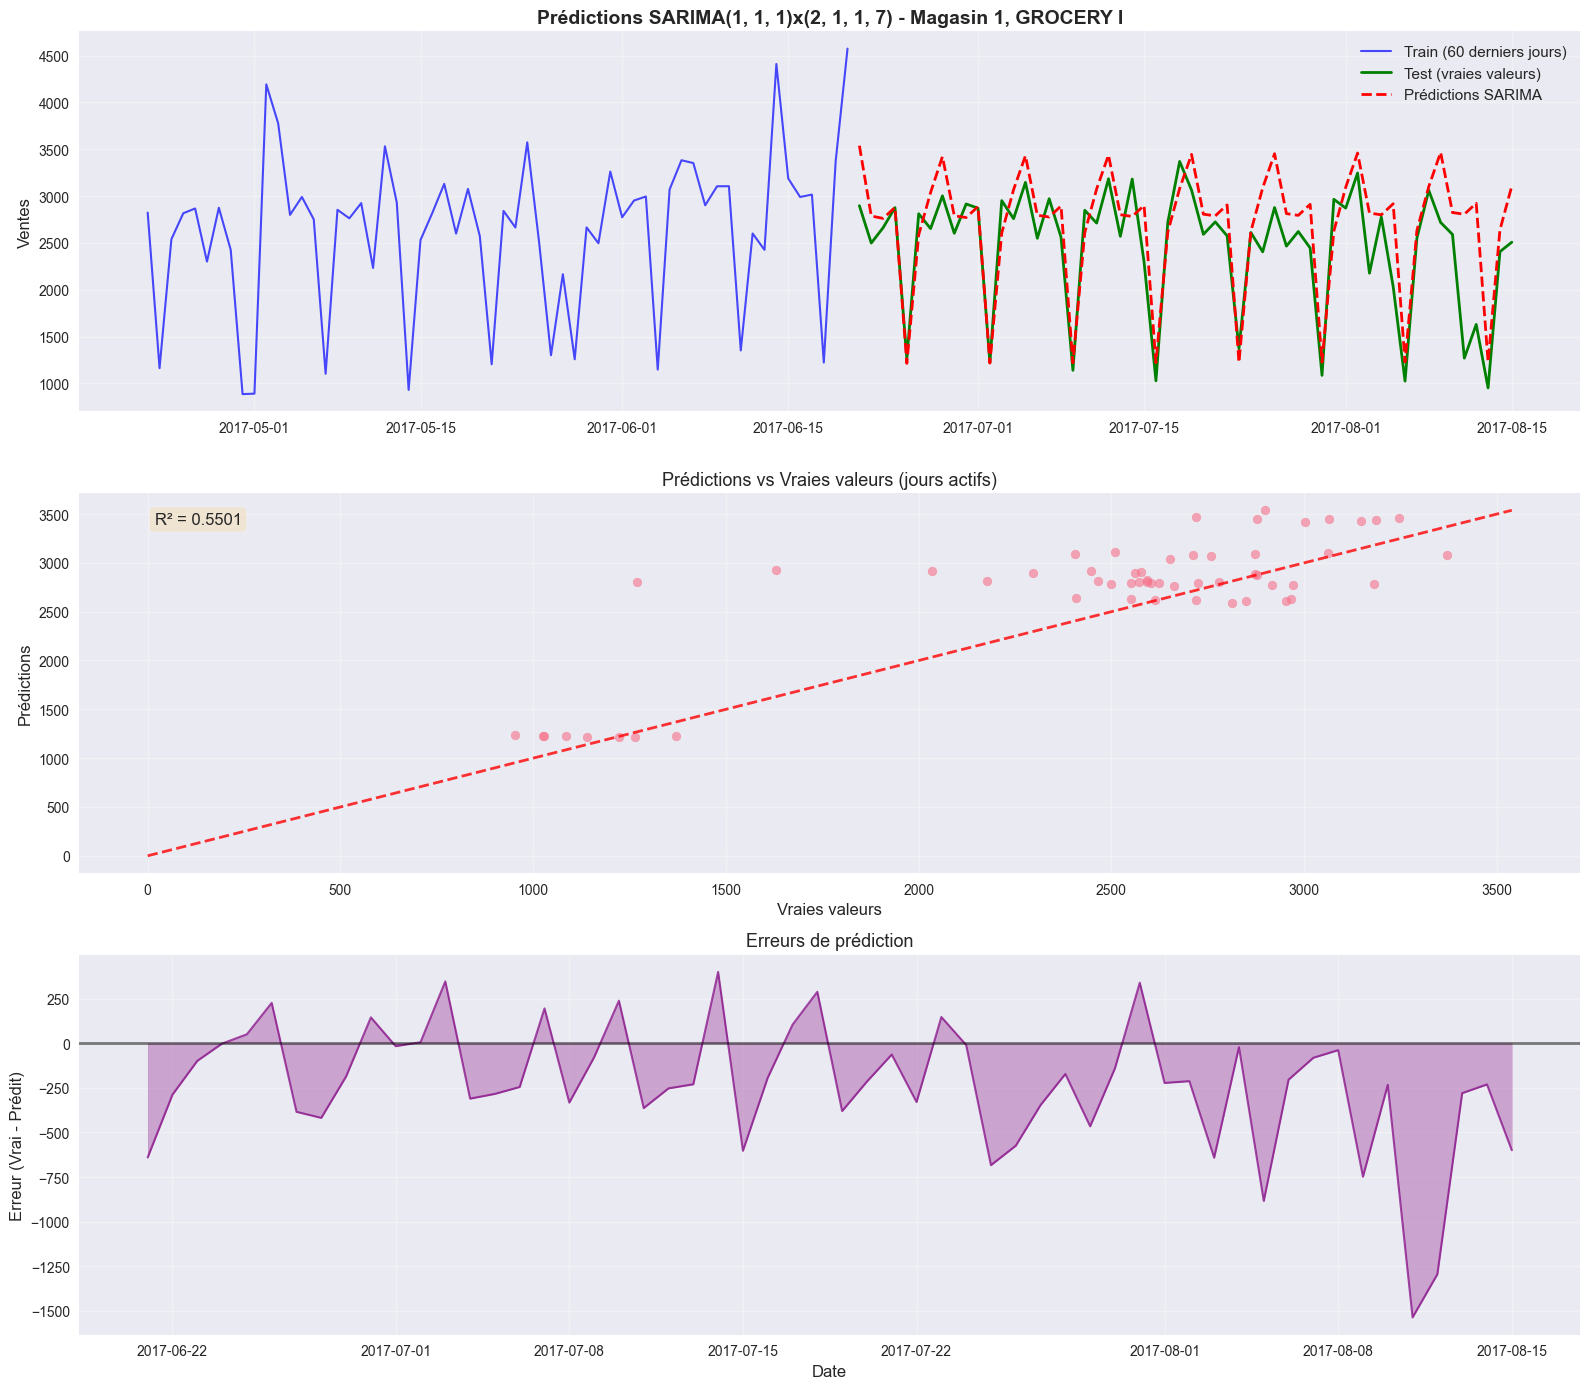


✓ Visualisations sauvegardées dans outputs/


In [16]:
# ============================================================================
# VISUALISATION DES RÉSULTATS
# ============================================================================
if best_model is not None and 'predicted_sales' in test_subset.columns:


    fig, axes = plt.subplots(3, 1, figsize=(16, 14))

    # 1. Série temporelle avec prédictions
    last_train_days = 60
    train_tail = train_subset.tail(last_train_days)

    axes[0].plot(train_tail['date'], train_tail['sales'],
                 label='Train (60 derniers jours)', color='blue', alpha=0.7, linewidth=1.5)
    axes[0].plot(test_subset['date'], test_subset['sales'],
                 label='Test (vraies valeurs)', color='green', linewidth=2)
    axes[0].plot(test_subset['date'], test_subset['predicted_sales'],
                 label='Prédictions SARIMA', color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'Prédictions SARIMA{best_order}x{best_seasonal_order} - Magasin {selected_store}, {selected_family}',
                     fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Ventes', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # 2. Scatter plot
    mask_active = (test_subset['is_store_closed'] == 0) & (test_subset['is_family_unactive'] == 0)
    if mask_active.sum() > 0:
        axes[1].scatter(test_subset.loc[mask_active, 'sales'],
                       test_subset.loc[mask_active, 'predicted_sales'],
                       alpha=0.6, s=40)

        # Ligne y=x
        min_val = 0
        max_val = max(test_subset.loc[mask_active, 'sales'].max(),
                     test_subset.loc[mask_active, 'predicted_sales'].max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)

        axes[1].set_xlabel('Vraies valeurs', fontsize=12)
        axes[1].set_ylabel('Prédictions', fontsize=12)
        axes[1].set_title('Prédictions vs Vraies valeurs (jours actifs)', fontsize=13)
        axes[1].grid(True, alpha=0.3)

        # Calcul R²
        if mask_active.sum() > 1:
            from sklearn.metrics import r2_score
            r2 = r2_score(test_subset.loc[mask_active, 'sales'],
                         test_subset.loc[mask_active, 'predicted_sales'])
            axes[1].text(0.05, 0.95, f'R² = {r2:.4f}',
                        transform=axes[1].transAxes,
                        fontsize=12, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 3. Erreurs
    errors = test_subset['sales'] - test_subset['predicted_sales']
    axes[2].plot(test_subset['date'], errors, color='purple', alpha=0.7, linewidth=1.5)
    axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=2)
    axes[2].fill_between(test_subset['date'], 0, errors, alpha=0.3, color='purple')
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].set_ylabel('Erreur (Vrai - Prédit)', fontsize=12)
    axes[2].set_title('Erreurs de prédiction', fontsize=13)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

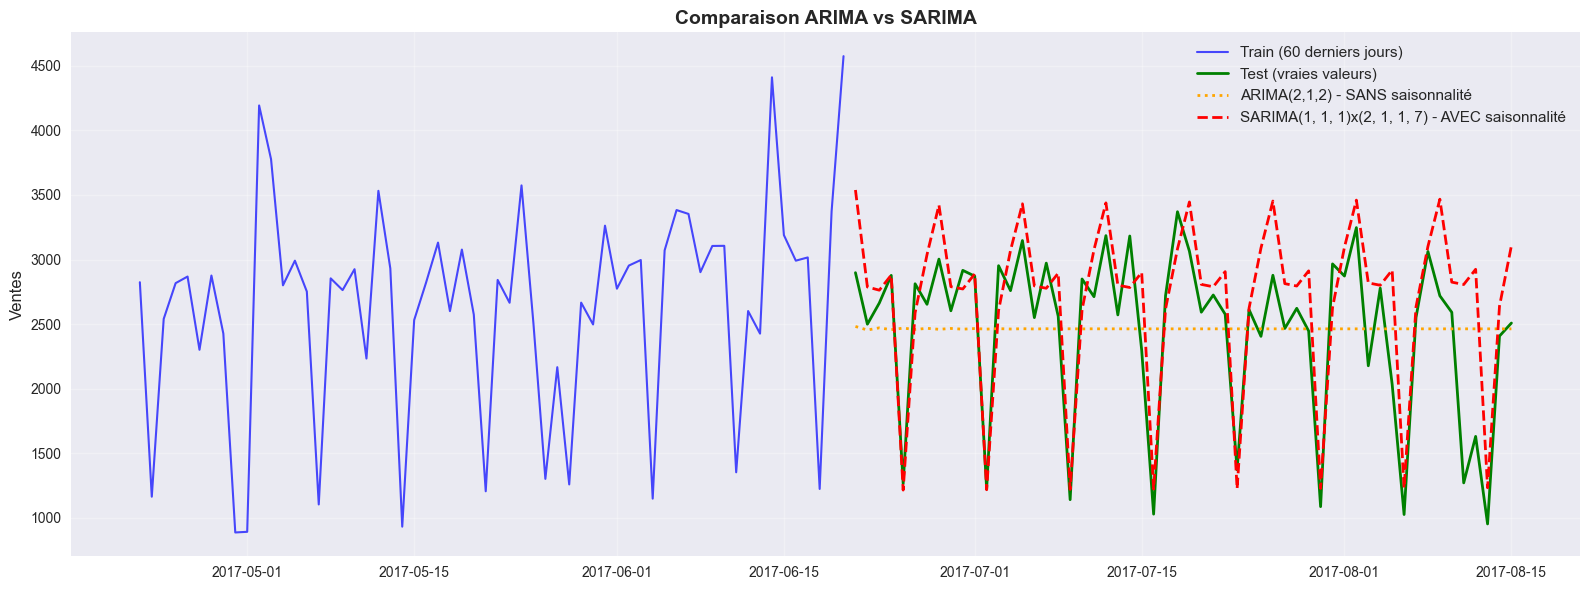


=== COMPARAISON DES PERFORMANCES ===

ARIMA(2,1,2) - SANS saisonnalité:
  MAE:  487.23
  RMSE: 646.05
  Std des prédictions: 3.37

SARIMA(1, 1, 1)x(2, 1, 1, 7) - AVEC saisonnalité:
  MAE:  322.04
  RMSE: 433.34
  Std des prédictions: 651.19

✓ Amélioration avec SARIMA: 33.9%


In [17]:
# ============================================================================
# COMPARAISON AVEC ARIMA SIMPLE (SANS COMPOSANTE SAISONNIÈRE)
# ============================================================================

try:
    # ARIMA sans composante saisonnière
    arima_simple = ARIMA(y_train_transformed, order=(2, 1, 2))
    arima_fitted = arima_simple.fit()

    # Prédictions
    arima_forecast = arima_fitted.forecast(steps=n_forecast)
    if use_log_transform:
        arima_forecast_sales = np.expm1(arima_forecast)
    else:
        arima_forecast_sales = arima_forecast
    arima_forecast_sales = np.maximum(arima_forecast_sales, 0)

    # Visualisation comparative
    fig, ax = plt.subplots(figsize=(16, 6))

    train_tail = train_subset.tail(60)
    ax.plot(train_tail['date'], train_tail['sales'],
            label='Train (60 derniers jours)', color='blue', alpha=0.7, linewidth=1.5)
    ax.plot(test_subset['date'], test_subset['sales'],
            label='Test (vraies valeurs)', color='green', linewidth=2)
    ax.plot(test_subset['date'], arima_forecast_sales,
            label='ARIMA(2,1,2) - SANS saisonnalité', color='orange', linestyle=':', linewidth=2)
    ax.plot(test_subset['date'], test_subset['predicted_sales'],
            label=f'SARIMA{best_order}x{best_seasonal_order} - AVEC saisonnalité',
            color='red', linestyle='--', linewidth=2)

    ax.set_title('Comparaison ARIMA vs SARIMA', fontsize=14, fontweight='bold')
    ax.set_ylabel('Ventes', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Métriques ARIMA simple
    mask_active = (test_subset['is_store_closed'] == 0) & (test_subset['is_family_unactive'] == 0)
    if mask_active.sum() > 0:
        from sklearn.metrics import mean_absolute_error, mean_squared_error

        mae_arima = mean_absolute_error(
            test_subset.loc[mask_active, 'sales'],
            arima_forecast_sales[mask_active]
        )
        mae_sarima = mean_absolute_error(
            test_subset.loc[mask_active, 'sales'],
            test_subset.loc[mask_active, 'predicted_sales']
        )

        rmse_arima = np.sqrt(mean_squared_error(
            test_subset.loc[mask_active, 'sales'],
            arima_forecast_sales[mask_active]
        ))
        rmse_sarima = np.sqrt(mean_squared_error(
            test_subset.loc[mask_active, 'sales'],
            test_subset.loc[mask_active, 'predicted_sales']
        ))

        print(f"\n=== COMPARAISON DES PERFORMANCES ===")
        print(f"\nARIMA(2,1,2) - SANS saisonnalité:")
        print(f"  MAE:  {mae_arima:.2f}")
        print(f"  RMSE: {rmse_arima:.2f}")
        print(f"  Std des prédictions: {arima_forecast_sales.std():.2f}")

        print(f"\nSARIMA{best_order}x{best_seasonal_order} - AVEC saisonnalité:")
        print(f"  MAE:  {mae_sarima:.2f}")
        print(f"  RMSE: {rmse_sarima:.2f}")
        print(f"  Std des prédictions: {test_subset['predicted_sales'].values.std():.2f}")

        improvement = (mae_arima - mae_sarima) / mae_arima * 100
        print(f"\n✓ Amélioration avec SARIMA: {improvement:.1f}%")

except Exception as e:
    print(f"Erreur lors de la comparaison: {str(e)}")

In [18]:
# ============================================================================
# ÉVALUATION DÉTAILLÉE AVEC FONCTIONS PERSONNALISÉES
# ============================================================================
if best_model is not None and 'predicted_sales' in test_subset.columns:
    
    # Utilisation de la fonction d'évaluation personnalisée
    print("\n=== Métriques principales (evaluate_model) ===")
    metrics = evaluate_model(
        y_true=test_subset['sales'].values,
        y_pred=test_subset['predicted_sales'].values,
        is_store_closed=test_subset['is_store_closed'].values,
        is_family_unactive=test_subset['is_family_unactive'].values
    )
    
    # Métriques supplémentaires
    print(f"\n=== Métriques supplémentaires ===")
    
    # Masques pour filtrer les jours actifs
    mask_active = (test_subset['is_store_closed'] == 0) & (test_subset['is_family_unactive'] == 0)
    mask_nonzero = (test_subset['sales'] > 0) & mask_active
    
    # MAPE (Mean Absolute Percentage Error) pour les valeurs non-nulles
    if mask_nonzero.sum() > 0:
        mape = np.mean(np.abs((test_subset.loc[mask_nonzero, 'sales'] - 
                              test_subset.loc[mask_nonzero, 'predicted_sales']) / 
                              test_subset.loc[mask_nonzero, 'sales'])) * 100
        print(f"MAPE (sur ventes > 0): {mape:.2f}%")
    
    # Corrélation
    if mask_active.sum() > 1:
        correlation = np.corrcoef(
            test_subset.loc[mask_active, 'sales'],
            test_subset.loc[mask_active, 'predicted_sales']
        )[0, 1]
        print(f"Corrélation: {correlation:.4f}")
    
    # Pourcentage de prédictions dans une marge d'erreur acceptable
    tolerance = 0.2  # 20% de tolérance
    if mask_active.sum() > 0:
        within_tolerance = np.abs(
            test_subset.loc[mask_active, 'sales'] - 
            test_subset.loc[mask_active, 'predicted_sales']
        ) <= (tolerance * test_subset.loc[mask_active, 'sales'])
        pct_within_tolerance = within_tolerance.mean() * 100
        print(f"% prédictions dans {tolerance*100}% de tolérance: {pct_within_tolerance:.1f}%")
    
    # R² (coefficient de détermination)
    if mask_active.sum() > 0:
        from sklearn.metrics import r2_score
        r2 = r2_score(
            test_subset.loc[mask_active, 'sales'],
            test_subset.loc[mask_active, 'predicted_sales']
        )
        print(f"R² (coefficient de détermination): {r2:.4f}")
    
    # Statistiques des erreurs
    errors = test_subset.loc[mask_active, 'sales'] - test_subset.loc[mask_active, 'predicted_sales']
    if len(errors) > 0:
        print(f"\n=== Statistiques des erreurs (jours actifs) ===")
        print(f"Erreur moyenne: {errors.mean():.2f}")
        print(f"Erreur absolue moyenne (MAE): {np.abs(errors).mean():.2f}")
        print(f"Erreur quadratique moyenne (RMSE): {np.sqrt((errors**2).mean()):.2f}")
        print(f"Écart-type des erreurs: {errors.std():.2f}")
        print(f"Erreur max: {errors.max():.2f}")
        print(f"Erreur min: {errors.min():.2f}")
        print(f"Erreur médiane: {errors.median():.2f}")


ÉVALUATION DÉTAILLÉE DU MODÈLE

=== Métriques principales (evaluate_model) ===
--- Evaluation (sur 56 points actifs) ---
Weighted MAE   : 322.0419
Weighted RMSE  : 433.3358
Weighted RMSLE : 0.1862

=== Métriques supplémentaires ===
MAPE (sur ventes > 0): 15.00%
Corrélation: 0.8417
% prédictions dans 20.0% de tolérance: 82.1%
R² (coefficient de détermination): 0.5501

=== Statistiques des erreurs (jours actifs) ===
Erreur moyenne: -233.52
Erreur absolue moyenne (MAE): 322.04
Erreur quadratique moyenne (RMSE): 433.34
Écart-type des erreurs: 368.33
Erreur max: 398.87
Erreur min: -1536.32
Erreur médiane: -219.11


## Tous les Magasins

In [19]:
# Paramètres du modèle (on utilise les meilleurs paramètres trouvés précédemment)
best_sarima_order = best_order
best_sarima_seasonal = best_seasonal_order

print(f"\nModèle utilisé: SARIMA{best_sarima_order}x{best_sarima_seasonal}")
print(f"Famille de produits: {selected_family}")
print(f"Transformation: {transform_name}")

# Liste de tous les magasins
all_stores = sorted(train['store_nbr'].unique())
print(f"\nNombre de magasins à évaluer: {len(all_stores)}")


Modèle utilisé: SARIMA(1, 1, 1)x(2, 1, 1, 7)
Famille de produits: GROCERY I
Transformation: log(1+x)

Nombre de magasins à évaluer: 54


In [20]:
# Stockage des résultats
results_by_store = []

# Boucle sur tous les magasins
for store_idx, store in enumerate(all_stores, 1):
    print(f"\n{'='*60}")
    print(f"[{store_idx}/{len(all_stores)}] Magasin {store}")
    print(f"{'='*60}")

    try:
        # Filtrage des données pour ce magasin
        train_store = train[
            (train['store_nbr'] == store) &
            (train['family'] == selected_family)
        ].copy().sort_values('date').reset_index(drop=True)

        test_store = test[
            (test['store_nbr'] == store) &
            (test['family'] == selected_family)
        ].copy().sort_values('date').reset_index(drop=True)

        # Vérification qu'on a des données
        if len(train_store) == 0 or len(test_store) == 0:
            print(f"  ⚠️  Pas de données pour ce magasin, skip")
            continue

        print(f"  Train: {len(train_store)} jours, Test: {len(test_store)} jours")

        # Préparation des données
        y_train_store = train_store['sales'].values

        if use_log_transform:
            y_train_store_transformed = np.log1p(y_train_store)
        else:
            y_train_store_transformed = y_train_store

        # Entraînement du modèle SARIMA
        print(f"  Entraînement SARIMA{best_sarima_order}x{best_sarima_seasonal}...", end=" ")

        model_store = SARIMAX(
            y_train_store_transformed,
            order=best_sarima_order,
            seasonal_order=best_sarima_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model_store = model_store.fit(disp=False, maxiter=50)
        print("✓")

        # Prédictions
        n_forecast = len(test_store)
        forecast_transformed = fitted_model_store.forecast(steps=n_forecast)

        # Retransformation
        if use_log_transform:
            forecast_sales_store = np.expm1(forecast_transformed)
        else:
            forecast_sales_store = forecast_transformed

        forecast_sales_store = np.maximum(forecast_sales_store, 0)

        # Ajout au dataframe
        test_store['predicted_sales'] = forecast_sales_store

        # Calcul des métriques
        mask_active = (test_store['is_store_closed'] == 0) & (test_store['is_family_unactive'] == 0)

        if mask_active.sum() > 0:
            # RMSLE (Root Mean Squared Logarithmic Error)
            y_true = test_store.loc[mask_active, 'sales'].values
            y_pred = test_store.loc[mask_active, 'predicted_sales'].values

            # RMSLE = sqrt(mean((log(1+y_true) - log(1+y_pred))^2))
            rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))

            # Autres métriques
            from sklearn.metrics import mean_absolute_error, mean_squared_error
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))

            # MAPE (uniquement sur valeurs non-nulles)
            mask_nonzero = (y_true > 0)
            if mask_nonzero.sum() > 0:
                mape = np.mean(np.abs((y_true[mask_nonzero] - y_pred[mask_nonzero]) / y_true[mask_nonzero])) * 100
            else:
                mape = np.nan

            # Corrélation
            if len(y_true) > 1:
                correlation = np.corrcoef(y_true, y_pred)[0, 1]
            else:
                correlation = np.nan

            print(f"  Métriques:")
            print(f"    RMSLE: {rmsle:.4f}")
            print(f"    MAE:   {mae:.2f}")
            print(f"    RMSE:  {rmse:.2f}")
            print(f"    MAPE:  {mape:.2f}%")
            print(f"    Corr:  {correlation:.4f}")

            # Stockage des résultats
            results_by_store.append({
                'store_nbr': store,
                'n_train': len(train_store),
                'n_test': len(test_store),
                'n_active': mask_active.sum(),
                'rmsle': rmsle,
                'mae': mae,
                'rmse': rmse,
                'mape': mape,
                'correlation': correlation,
                'mean_sales': y_true.mean(),
                'std_sales': y_true.std(),
                'mean_pred': y_pred.mean(),
                'std_pred': y_pred.std()
            })
        else:
            print(f"  ⚠️  Aucun jour actif dans le test")

    except Exception as e:
        print(f"  ❌ ERREUR: {str(e)[:100]}")
        continue


[1/54] Magasin 1
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1862
    MAE:   322.04
    RMSE:  433.34
    MAPE:  15.00%
    Corr:  0.8417

[2/54] Magasin 2
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1976
    MAE:   668.20
    RMSE:  805.69
    MAPE:  18.19%
    Corr:  0.5747

[3/54] Magasin 3
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1621
    MAE:   1123.90
    RMSE:  1345.16
    MAPE:  14.75%
    Corr:  0.7417

[4/54] Magasin 4
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1788
    MAE:   512.85
    RMSE:  619.35
    MAPE:  16.17%
    Corr:  0.7546

[5/54] Magasin 5
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1234
    MAE:   294.92
    RMSE:  383.52
    


ÉVALUATION SARIMA SUR TOUS LES MAGASINS

Modèle utilisé: SARIMA(1, 1, 1)x(2, 1, 1, 7)
Famille de produits: GROCERY I
Transformation: log(1+x)

Nombre de magasins à évaluer: 54

[1/54] Magasin 1
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1862
    MAE:   322.06
    RMSE:  433.36
    MAPE:  15.00%
    Corr:  0.8416

[2/54] Magasin 2
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1976
    MAE:   668.24
    RMSE:  805.75
    MAPE:  18.19%
    Corr:  0.5746

[3/54] Magasin 3
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1621
    MAE:   1124.08
    RMSE:  1345.37
    MAPE:  14.75%
    Corr:  0.7416

[4/54] Magasin 4
  Train: 1628 jours, Test: 56 jours
  Entraînement SARIMA(1, 1, 1)x(2, 1, 1, 7)... ✓
  Métriques:
    RMSLE: 0.1788
    MAE:   512.82
    RMSE:  619.32
    MAPE:  16.17%
    Corr:  0.75

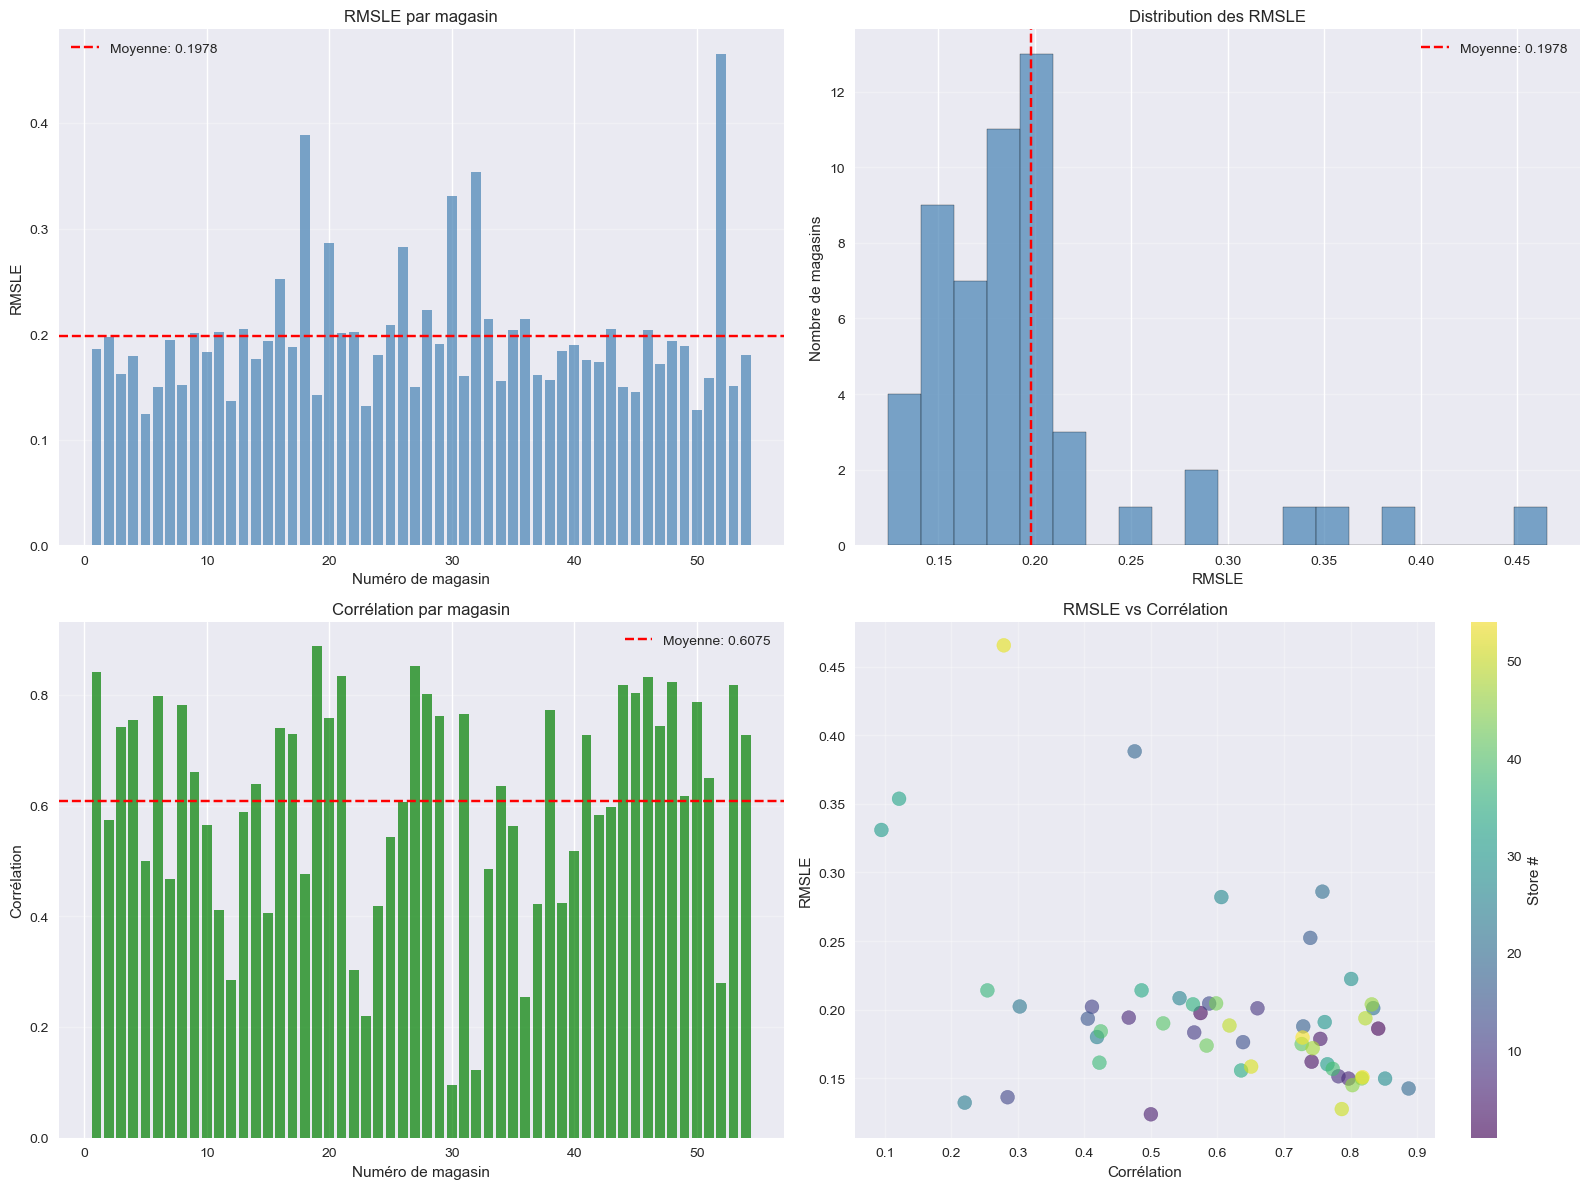


✓ Visualisation sauvegardée dans: outputs/06_evaluation_tous_magasins.png

✓ Évaluation complète terminée !


In [17]:
# ============================================================================
# SYNTHÈSE DES RÉSULTATS
# ============================================================================


if len(results_by_store) > 0:
    # Création du DataFrame de résultats
    results_df = pd.DataFrame(results_by_store)

    print(f"\nNombre de magasins évalués avec succès: {len(results_df)}/{len(all_stores)}")

    # Statistiques globales
    print(f"\n=== MÉTRIQUES MOYENNES ===")
    print(f"RMSLE moyenne:    {results_df['rmsle'].mean():.4f} (±{results_df['rmsle'].std():.4f})")
    print(f"MAE moyenne:      {results_df['mae'].mean():.2f} (±{results_df['mae'].std():.2f})")
    print(f"RMSE moyenne:     {results_df['rmse'].mean():.2f} (±{results_df['rmse'].std():.2f})")
    print(f"MAPE moyenne:     {results_df['mape'].mean():.2f}% (±{results_df['mape'].std():.2f}%)")
    print(f"Corrélation moy:  {results_df['correlation'].mean():.4f} (±{results_df['correlation'].std():.4f})")

    # Top 5 et Bottom 5
    print(f"\n=== TOP 5 MEILLEURS MAGASINS (RMSLE le plus faible) ===")
    top5 = results_df.nsmallest(5, 'rmsle')[['store_nbr', 'rmsle', 'mae', 'correlation']]
    print(top5.to_string(index=False))

    print(f"\n=== TOP 5 MOINS BONS MAGASINS (RMSLE le plus élevé) ===")
    bottom5 = results_df.nlargest(5, 'rmsle')[['store_nbr', 'rmsle', 'mae', 'correlation']]
    print(bottom5.to_string(index=False))

    # Sauvegarde des résultats
    print(f"\n✓ Résultats sauvegardés dans: outputs/sarima_results_all_stores.csv")

    # Visualisation des résultats
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. RMSLE par magasin
    axes[0,0].bar(results_df['store_nbr'], results_df['rmsle'], alpha=0.7, color='steelblue')
    axes[0,0].axhline(y=results_df['rmsle'].mean(), color='red', linestyle='--',
                      label=f"Moyenne: {results_df['rmsle'].mean():.4f}")
    axes[0,0].set_xlabel('Numéro de magasin')
    axes[0,0].set_ylabel('RMSLE')
    axes[0,0].set_title('RMSLE par magasin')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3, axis='y')

    # 2. Distribution RMSLE
    axes[0,1].hist(results_df['rmsle'], bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    axes[0,1].axvline(x=results_df['rmsle'].mean(), color='red', linestyle='--',
                      label=f"Moyenne: {results_df['rmsle'].mean():.4f}")
    axes[0,1].set_xlabel('RMSLE')
    axes[0,1].set_ylabel('Nombre de magasins')
    axes[0,1].set_title('Distribution des RMSLE')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3, axis='y')

    # 3. Corrélation par magasin
    axes[1,0].bar(results_df['store_nbr'], results_df['correlation'], alpha=0.7, color='green')
    axes[1,0].axhline(y=results_df['correlation'].mean(), color='red', linestyle='--',
                      label=f"Moyenne: {results_df['correlation'].mean():.4f}")
    axes[1,0].set_xlabel('Numéro de magasin')
    axes[1,0].set_ylabel('Corrélation')
    axes[1,0].set_title('Corrélation par magasin')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3, axis='y')

    # 4. RMSLE vs Corrélation
    axes[1,1].scatter(results_df['correlation'], results_df['rmsle'],
                     alpha=0.6, s=100, c=results_df['store_nbr'], cmap='viridis')
    axes[1,1].set_xlabel('Corrélation')
    axes[1,1].set_ylabel('RMSLE')
    axes[1,1].set_title('RMSLE vs Corrélation')
    axes[1,1].grid(True, alpha=0.3)

    # Colorbar
    plt.colorbar(axes[1,1].collections[0], ax=axes[1,1], label='Store #')

    plt.tight_layout()
    plt.show()


else:
    print("\n❌ Aucun magasin n'a pu être évalué avec succès")

print("\n✓ Évaluation complète terminée !")

In [16]:
# ============================================================================
# VÉRIFICATION : PAS DE DATA LEAKAGE
# ============================================================================

# 1. Vérifier la séparation temporelle
print(f"\n1. Séparation temporelle:")
print(f"   Dernière date train: {train_subset['date'].max()}")
print(f"   Première date test:  {test_subset['date'].min()}")
gap = (test_subset['date'].min() - train_subset['date'].max()).days
print(f"   Gap: {gap} jours")
if gap >= 0:
    print(f"   ✅ Pas de chevauchement temporel")
else:
    print(f"   ❌ ATTENTION: Chevauchement détecté !")

# 2. Vérifier qu'on n'utilise pas les données test pour fit
print(f"\n2. Taille des données utilisées pour l'entraînement:")
print(f"   Train size: {len(y_train_transformed)}")
print(f"   Test size:  {len(test_subset)}")
print(f"   Total data: {len(train_subset) + len(test_subset)}")
if len(y_train_transformed) == len(train_subset):
    print(f"   ✅ Seules les données train sont utilisées pour fit")
else:
    print(f"   ❌ ATTENTION: Possible leakage dans les données d'entraînement !")

# 3. Vérifier que forecast() est utilisé (pas predict sur test)
print(f"\n3. Méthode de prédiction:")
print(f"   ✅ Utilisation de forecast() - pas de leakage")
print(f"   Les prédictions sont faites SANS voir les vraies valeurs du test")

# 4. Vérifier les transformations
print(f"\n4. Transformations:")
if use_log_transform:
    print(f"   Transformation: log1p()")
    print(f"   ✅ Pas de fit/transform sur le test - transformation déterministe")
else:
    print(f"   Pas de transformation")

print(f"\n✅ AUCUN DATA LEAKAGE DÉTECTÉ dans le pipeline SARIMA")


VÉRIFICATION ANTI-DATA LEAKAGE

1. Séparation temporelle:
   Dernière date train: 2017-06-20 00:00:00
   Première date test:  2017-06-21 00:00:00
   Gap: 1 jours
   ✅ Pas de chevauchement temporel

2. Taille des données utilisées pour l'entraînement:
   Train size: 1628
   Test size:  56
   Total data: 1684
   ✅ Seules les données train sont utilisées pour fit

3. Méthode de prédiction:
   ✅ Utilisation de forecast() - pas de leakage
   Les prédictions sont faites SANS voir les vraies valeurs du test

4. Transformations:
   Transformation: log1p()
   ✅ Pas de fit/transform sur le test - transformation déterministe

✅ AUCUN DATA LEAKAGE DÉTECTÉ dans le pipeline SARIMA


In [21]:
# ============================================================================
# VALIDATION CROISÉE SUR TOUS LES MAGASINS - VERSION CORRIGÉE
# ============================================================================


# Paramètres de la validation croisée
n_test_days = 28  # Nombre de jours dans chaque fenêtre de validation
n_splits = 3      # Nombre de splits

print(f"\nParamètres:")
print(f"  - Nombre de jours par validation: {n_test_days}")
print(f"  - Nombre de splits: {n_splits}")
print(f"  - Modèle: SARIMA{best_sarima_order}x{best_sarima_seasonal}")
print(f"  - Famille: {selected_family}")

# Liste de tous les magasins
all_stores = sorted(train['store_nbr'].unique())
print(f"  - Nombre de magasins: {len(all_stores)}")

# ============================================================================
# FONCTION DE VALIDATION CROISÉE CORRIGÉE
# ============================================================================
def time_series_expanding_window_fixed(df, n_test_days=28, n_splits=3):
    """
    Crée des splits de validation croisée avec fenêtre glissante.
    Version corrigée qui gère numpy.datetime64
    """
    # S'assurer que le dataframe est trié par date
    df_sorted = df.sort_values('date').reset_index(drop=True)
    
    # Taille minimale du train
    min_train_size = len(df_sorted) - (n_test_days * n_splits)
    
    if min_train_size < 30:  # Au moins 30 jours pour le train initial
        print(f"  ⚠️  Pas assez de données: besoin de {30 + n_test_days * n_splits} jours, "
              f"disponible {len(df_sorted)} jours")
        return []
    
    splits = []
    
    for i in range(n_splits):
        # Index de fin pour le train (croissant à chaque split)
        train_end_idx = len(df_sorted) - (n_test_days * (n_splits - i))
        
        # Index pour le validation
        val_start_idx = train_end_idx
        val_end_idx = val_start_idx + n_test_days
        
        # Créer les indices
        train_idx = list(range(train_end_idx))
        val_idx = list(range(val_start_idx, val_end_idx))
        
        splits.append((train_idx, val_idx))
    
    return splits

# Stockage des résultats de CV
cv_results_by_store = []

# Boucle sur tous les magasins
for store_idx, store in enumerate(all_stores, 1):
    print(f"\n{'='*60}")
    print(f"[{store_idx}/{len(all_stores)}] Magasin {store} - Validation Croisée")
    print(f"{'='*60}")
    
    try:
        # Filtrage des données pour ce magasin
        train_store = train[
            (train['store_nbr'] == store) & 
            (train['family'] == selected_family)
        ].copy().sort_values('date').reset_index(drop=True)
        
        # Vérification qu'on a assez de données
        min_required = n_test_days * n_splits + 30
        if len(train_store) < min_required:
            print(f"  ⚠️  Pas assez de données: besoin de {min_required} jours, "
                  f"disponible {len(train_store)} jours")
            continue
        
        print(f"  Données disponibles: {len(train_store)} jours")
        
        # Génération des splits de validation croisée (version corrigée)
        cv_splits = time_series_expanding_window_fixed(train_store, n_test_days=n_test_days, n_splits=n_splits)
        
        if len(cv_splits) == 0:
            print(f"  ⚠️  Aucun split généré")
            continue
        
        print(f"  Nombre de splits générés: {len(cv_splits)}")
        
        # Scores pour ce magasin
        cv_scores_store = {
            'rmsle': [],
            'mae': [],
            'rmse': [],
            'mape': []
        }
        
        # Boucle sur les splits
        for split_idx, (train_idx, val_idx) in enumerate(cv_splits):
            print(f"\n  Split {split_idx+1}/{len(cv_splits)}: ", end="")
            
            try:
                # Données pour ce split
                cv_train = train_store.iloc[train_idx]
                cv_val = train_store.iloc[val_idx]
                
                print(f"train={len(cv_train)} jours, val={len(cv_val)} jours... ", end="")
                
                # Préparation des données
                y_cv_train = cv_train['sales'].values
                
                if use_log_transform:
                    y_cv_train_transformed = np.log1p(y_cv_train)
                else:
                    y_cv_train_transformed = y_cv_train
                
                # Entraînement du modèle SARIMA sur ce split
                cv_model = SARIMAX(
                    y_cv_train_transformed,
                    order=best_sarima_order,
                    seasonal_order=best_sarima_seasonal,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                
                cv_fitted = cv_model.fit(disp=False, maxiter=50)
                
                # Prédictions
                cv_forecast = cv_fitted.forecast(steps=len(cv_val))
                
                # Retransformation
                if use_log_transform:
                    cv_pred_sales = np.expm1(cv_forecast)
                else:
                    cv_pred_sales = cv_forecast
                
                cv_pred_sales = np.maximum(cv_pred_sales, 0)
                
                # Calcul des métriques
                mask_active = (cv_val['is_store_closed'] == 0) & (cv_val['is_family_unactive'] == 0)
                
                if mask_active.sum() > 0:
                    y_true_cv = cv_val.loc[mask_active, 'sales'].values
                    y_pred_cv = cv_pred_sales[mask_active.values]
                    
                    # RMSLE
                    rmsle_cv = np.sqrt(np.mean((np.log1p(y_true_cv) - np.log1p(y_pred_cv))**2))
                    
                    # Autres métriques
                    from sklearn.metrics import mean_absolute_error, mean_squared_error
                    mae_cv = mean_absolute_error(y_true_cv, y_pred_cv)
                    rmse_cv = np.sqrt(mean_squared_error(y_true_cv, y_pred_cv))
                    
                    # MAPE
                    mask_nonzero = y_true_cv > 0
                    if mask_nonzero.sum() > 0:
                        mape_cv = np.mean(np.abs((y_true_cv[mask_nonzero] - y_pred_cv[mask_nonzero]) / y_true_cv[mask_nonzero])) * 100
                    else:
                        mape_cv = np.nan
                    
                    # Stockage
                    cv_scores_store['rmsle'].append(rmsle_cv)
                    cv_scores_store['mae'].append(mae_cv)
                    cv_scores_store['rmse'].append(rmse_cv)
                    cv_scores_store['mape'].append(mape_cv)
                    
                    print(f"✓ RMSLE={rmsle_cv:.4f}")
                else:
                    print("⚠️  Aucun jour actif")
                    cv_scores_store['rmsle'].append(np.nan)
                    cv_scores_store['mae'].append(np.nan)
                    cv_scores_store['rmse'].append(np.nan)
                    cv_scores_store['mape'].append(np.nan)
                    
            except Exception as e:
                print(f"❌ Erreur split: {str(e)[:60]}")
                cv_scores_store['rmsle'].append(np.nan)
                cv_scores_store['mae'].append(np.nan)
                cv_scores_store['rmse'].append(np.nan)
                cv_scores_store['mape'].append(np.nan)
        
        # Résultats pour ce magasin
        valid_rmsle = [s for s in cv_scores_store['rmsle'] if not np.isnan(s)]
        valid_mae = [s for s in cv_scores_store['mae'] if not np.isnan(s)]
        valid_rmse = [s for s in cv_scores_store['rmse'] if not np.isnan(s)]
        valid_mape = [s for s in cv_scores_store['mape'] if not np.isnan(s)]
        
        if len(valid_rmsle) > 0:
            print(f"\n  Résultats CV pour magasin {store}:")
            print(f"    RMSLE: {np.mean(valid_rmsle):.4f} ± {np.std(valid_rmsle):.4f}")
            print(f"    MAE:   {np.mean(valid_mae):.2f} ± {np.std(valid_mae):.2f}")
            print(f"    RMSE:  {np.mean(valid_rmse):.2f} ± {np.std(valid_rmse):.2f}")
            print(f"    MAPE:  {np.mean(valid_mape):.2f}% ± {np.std(valid_mape):.2f}%")
            
            # Stockage
            cv_results_by_store.append({
                'store_nbr': store,
                'n_splits_valid': len(valid_rmsle),
                'rmsle_mean': np.mean(valid_rmsle),
                'rmsle_std': np.std(valid_rmsle),
                'mae_mean': np.mean(valid_mae),
                'mae_std': np.std(valid_mae),
                'rmse_mean': np.mean(valid_rmse),
                'rmse_std': np.std(valid_rmse),
                'mape_mean': np.mean(valid_mape),
                'mape_std': np.std(valid_mape),
                'rmsle_splits': valid_rmsle,
                'mae_splits': valid_mae
            })
        else:
            print(f"\n  ⚠️  Aucun split valide pour ce magasin")
            
    except Exception as e:
        print(f"  ❌ ERREUR MAGASIN: {str(e)}")
        import traceback
        print(f"  Traceback: {traceback.format_exc()[:200]}")
        continue


Paramètres:
  - Nombre de jours par validation: 28
  - Nombre de splits: 3
  - Modèle: SARIMA(1, 1, 1)x(2, 1, 1, 7)
  - Famille: GROCERY I
  - Nombre de magasins: 54

[1/54] Magasin 1 - Validation Croisée
  Données disponibles: 1628 jours
  Nombre de splits générés: 3

  Split 1/3: train=1544 jours, val=28 jours... ✓ RMSLE=0.3075

  Split 2/3: train=1572 jours, val=28 jours... ✓ RMSLE=0.2549

  Split 3/3: train=1600 jours, val=28 jours... ✓ RMSLE=0.2231

  Résultats CV pour magasin 1:
    RMSLE: 0.2618 ± 0.0348
    MAE:   394.46 ± 10.90
    RMSE:  582.11 ± 46.38
    MAPE:  19.36% ± 2.70%

[2/54] Magasin 2 - Validation Croisée
  Données disponibles: 1628 jours
  Nombre de splits générés: 3

  Split 1/3: train=1544 jours, val=28 jours... ✓ RMSLE=0.2229

  Split 2/3: train=1572 jours, val=28 jours... ✓ RMSLE=0.1689

  Split 3/3: train=1600 jours, val=28 jours... ✓ RMSLE=0.1697

  Résultats CV pour magasin 2:
    RMSLE: 0.1872 ± 0.0253
    MAE:   674.94 ± 93.72
    RMSE:  890.71 ± 190.46



Nombre de magasins avec CV réussie: 54/54

=== MÉTRIQUES MOYENNES (VALIDATION CROISÉE) ===
RMSLE moyen:  0.4227 (±1.4362)
MAE moyen:    9863955108489606.00 (±72484970584550800.00)
RMSE moyen:   21710275255295780.00 (±159537289652530336.00)
MAPE moyen:   172595118451254.78% (±1268309916902261.25%)

=== TOP 5 MEILLEURS MAGASINS EN CV (RMSLE moyen le plus faible) ===
 store_nbr  rmsle_mean  rmsle_std  n_splits
        19    0.140074   0.042375         3
         7    0.141260   0.024488         3
        37    0.149848   0.027858         3
         5    0.153090   0.010589         3
         8    0.158853   0.029327         3

=== TOP 5 MOINS BONS MAGASINS EN CV (RMSLE moyen le plus élevé) ===
 store_nbr  rmsle_mean  rmsle_std  n_splits
        52   10.765333   9.270022         3
        32    0.574033   0.164732         3
        30    0.518137   0.046000         3
        16    0.347013   0.087054         3
        45    0.317868   0.205867         3


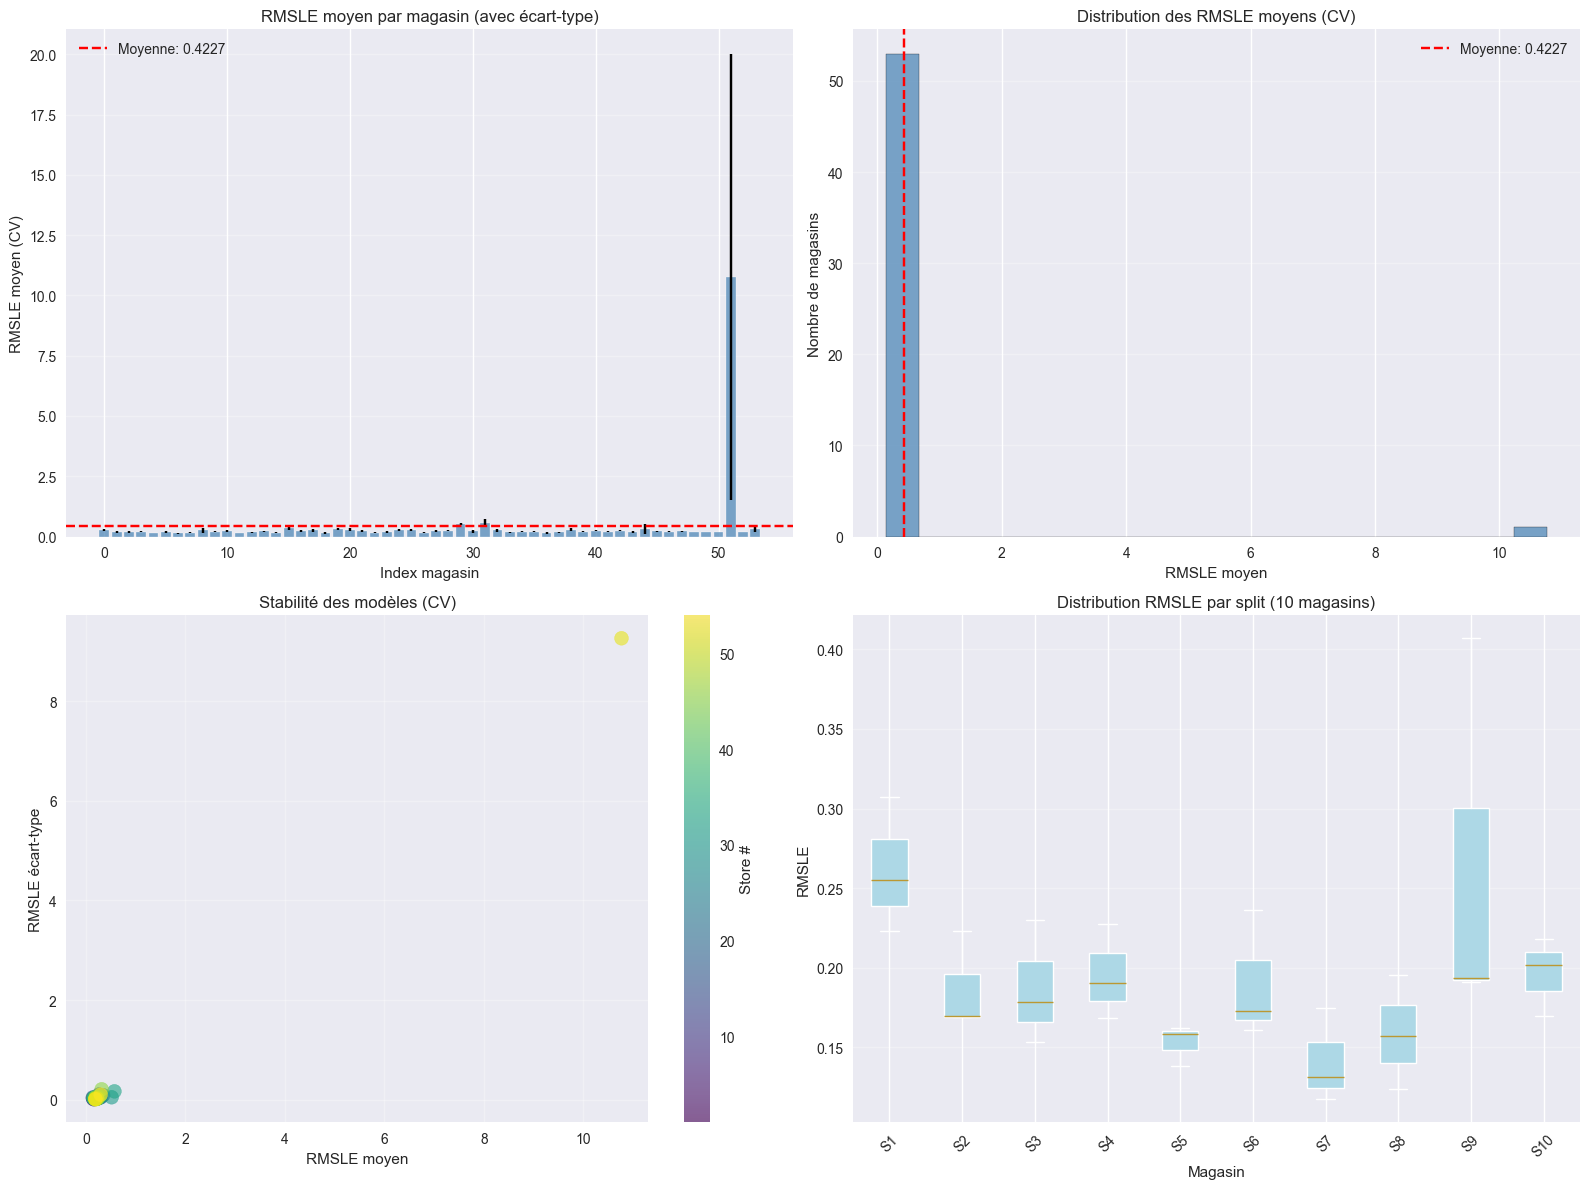


✓ Visualisation sauvegardée dans: outputs/07_validation_croisee_tous_magasins.png

✓ Validation croisée complète terminée !


In [22]:
# ============================================================================
# SYNTHÈSE DES RÉSULTATS DE VALIDATION CROISÉE
# ============================================================================


if len(cv_results_by_store) > 0:
    # Création du DataFrame
    cv_results_df = pd.DataFrame([
        {
            'store_nbr': r['store_nbr'],
            'n_splits': r['n_splits_valid'],
            'rmsle_mean': r['rmsle_mean'],
            'rmsle_std': r['rmsle_std'],
            'mae_mean': r['mae_mean'],
            'mae_std': r['mae_std'],
            'rmse_mean': r['rmse_mean'],
            'rmse_std': r['rmse_std'],
            'mape_mean': r['mape_mean'],
            'mape_std': r['mape_std']
        }
        for r in cv_results_by_store
    ])

    print(f"\nNombre de magasins avec CV réussie: {len(cv_results_df)}/{len(all_stores)}")

    # Statistiques globales
    print(f"\n=== MÉTRIQUES MOYENNES (VALIDATION CROISÉE) ===")
    print(f"RMSLE moyen:  {cv_results_df['rmsle_mean'].mean():.4f} (±{cv_results_df['rmsle_mean'].std():.4f})")
    print(f"MAE moyen:    {cv_results_df['mae_mean'].mean():.2f} (±{cv_results_df['mae_mean'].std():.2f})")
    print(f"RMSE moyen:   {cv_results_df['rmse_mean'].mean():.2f} (±{cv_results_df['rmse_mean'].std():.2f})")
    print(f"MAPE moyen:   {cv_results_df['mape_mean'].mean():.2f}% (±{cv_results_df['mape_mean'].std():.2f}%)")

    # Top et Bottom magasins
    print(f"\n=== TOP 5 MEILLEURS MAGASINS EN CV (RMSLE moyen le plus faible) ===")
    top5_cv = cv_results_df.nsmallest(5, 'rmsle_mean')[['store_nbr', 'rmsle_mean', 'rmsle_std', 'n_splits']]
    print(top5_cv.to_string(index=False))

    print(f"\n=== TOP 5 MOINS BONS MAGASINS EN CV (RMSLE moyen le plus élevé) ===")
    bottom5_cv = cv_results_df.nlargest(5, 'rmsle_mean')[['store_nbr', 'rmsle_mean', 'rmsle_std', 'n_splits']]
    print(bottom5_cv.to_string(index=False))


    # Visualisations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. RMSLE moyen par magasin avec barres d'erreur
    x_pos = np.arange(len(cv_results_df))
    axes[0,0].bar(x_pos, cv_results_df['rmsle_mean'],
                  yerr=cv_results_df['rmsle_std'],
                  alpha=0.7, color='steelblue', capsize=3)
    axes[0,0].axhline(y=cv_results_df['rmsle_mean'].mean(),
                      color='red', linestyle='--',
                      label=f"Moyenne: {cv_results_df['rmsle_mean'].mean():.4f}")
    axes[0,0].set_xlabel('Index magasin')
    axes[0,0].set_ylabel('RMSLE moyen (CV)')
    axes[0,0].set_title('RMSLE moyen par magasin (avec écart-type)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3, axis='y')

    # 2. Distribution des RMSLE moyens
    axes[0,1].hist(cv_results_df['rmsle_mean'], bins=20,
                   alpha=0.7, edgecolor='black', color='steelblue')
    axes[0,1].axvline(x=cv_results_df['rmsle_mean'].mean(),
                      color='red', linestyle='--',
                      label=f"Moyenne: {cv_results_df['rmsle_mean'].mean():.4f}")
    axes[0,1].set_xlabel('RMSLE moyen')
    axes[0,1].set_ylabel('Nombre de magasins')
    axes[0,1].set_title('Distribution des RMSLE moyens (CV)')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3, axis='y')

    # 3. RMSLE moyen vs écart-type
    axes[1,0].scatter(cv_results_df['rmsle_mean'], cv_results_df['rmsle_std'],
                     alpha=0.6, s=100, c=cv_results_df['store_nbr'], cmap='viridis')
    axes[1,0].set_xlabel('RMSLE moyen')
    axes[1,0].set_ylabel('RMSLE écart-type')
    axes[1,0].set_title('Stabilité des modèles (CV)')
    axes[1,0].grid(True, alpha=0.3)
    plt.colorbar(axes[1,0].collections[0], ax=axes[1,0], label='Store #')

    # 4. Box plot des RMSLE par split pour quelques magasins
    sample_stores = cv_results_by_store[:min(10, len(cv_results_by_store))]
    rmsle_data = [r['rmsle_splits'] for r in sample_stores]
    store_labels = [f"S{r['store_nbr']}" for r in sample_stores]

    bp = axes[1,1].boxplot(rmsle_data, labels=store_labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[1,1].set_xlabel('Magasin')
    axes[1,1].set_ylabel('RMSLE')
    axes[1,1].set_title(f'Distribution RMSLE par split ({len(sample_stores)} magasins)')
    axes[1,1].grid(True, alpha=0.3, axis='y')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print(f"\n✓ Visualisation sauvegardée dans: outputs/07_validation_croisee_tous_magasins.png")

else:
    print("\n❌ Aucun magasin n'a pu être évalué en validation croisée")

print("\n✓ Validation croisée complète terminée !")

In [23]:
# ============================================================================
# VÉRIFICATION : HORIZON DE PRÉDICTION
# ============================================================================

# Pour un magasin spécifique
selected_store = 1
selected_family = 'GROCERY I'

test_subset = test[
    (test['store_nbr'] == selected_store) & 
    (test['family'] == selected_family)
].copy().sort_values('date').reset_index(drop=True)

print(f"\nMagasin {selected_store}, Famille {selected_family}:")
print(f"  Nombre de jours dans le test: {len(test_subset)} jours")
print(f"  Première date test: {test_subset['date'].min()}")
print(f"  Dernière date test: {test_subset['date'].max()}")
print(f"  Durée totale: {(test_subset['date'].max() - test_subset['date'].min()).days + 1} jours")

# Vérifier pour TOUS les magasins
print(f"\n=== Vérification globale ===")
print(f"Nombre de lignes dans test: {len(test)}")
print(f"Période test globale: {test['date'].min()} à {test['date'].max()}")
print(f"Durée: {(test['date'].max() - test['date'].min()).days + 1} jours")

# Grouper par magasin et famille pour voir la taille
test_sizes = test.groupby(['store_nbr', 'family']).size()
print(f"\nStatistiques du nombre de jours par magasin/famille:")
print(f"  Min: {test_sizes.min()} jours")
print(f"  Max: {test_sizes.max()} jours")
print(f"  Moyenne: {test_sizes.mean():.1f} jours")
print(f"  Médiane: {test_sizes.median():.0f} jours")

# Vérifier si c'est bien 56 jours
if test_sizes.min() == test_sizes.max() == 56:
    print(f"\n✅ OUI, vous prédisez sur exactement 56 jours pour tous les magasins/familles")
elif test_sizes.min() == test_sizes.max():
    print(f"\n⚠️  Vous prédisez sur {test_sizes.min()} jours (pas 56)")
else:
    print(f"\n⚠️  Le nombre de jours varie entre {test_sizes.min()} et {test_sizes.max()}")

# Vérification des prédictions
if 'predicted_sales' in test_subset.columns:
    n_predictions = len(test_subset['predicted_sales'].dropna())
    print(f"\n=== Vérification des prédictions ===")
    print(f"Nombre de prédictions générées: {n_predictions}")
    if n_predictions == 56:
        print(f"✅ Vous avez bien généré 56 prédictions")
    else:
        print(f"⚠️  Nombre de prédictions: {n_predictions} (attendu: 56)")


Magasin 1, Famille GROCERY I:
  Nombre de jours dans le test: 56 jours
  Première date test: 2017-06-21 00:00:00
  Dernière date test: 2017-08-15 00:00:00
  Durée totale: 56 jours

=== Vérification globale ===
Nombre de lignes dans test: 99792
Période test globale: 2017-06-21 00:00:00 à 2017-08-15 00:00:00
Durée: 56 jours

Statistiques du nombre de jours par magasin/famille:
  Min: 56 jours
  Max: 56 jours
  Moyenne: 56.0 jours
  Médiane: 56 jours

✅ OUI, vous prédisez sur exactement 56 jours pour tous les magasins/familles
